In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("sales_cleaned.csv")

df['Inv.Date'] = pd.to_datetime(df['Inv.Date'])

In [2]:
total_volume = df['Billed Qty (CBM)'].sum()

total_customers = df['Customer Name'].nunique()

total_territories = df['Territory'].nunique()

total_materials = df['Material'].nunique()

print(f"Total Volume (CBM): {total_volume:,.2f}")
print(f"Total Customers: {total_customers}")
print(f"Total Territories: {total_territories}")
print(f"Total Materials: {total_materials}")

Total Volume (CBM): 175,154.16
Total Customers: 626
Total Territories: 69
Total Materials: 5055


In [3]:
monthly_volume = (
    df.groupby('Year_Month')['Billed Qty (CBM)']
      .sum()
      .reset_index()
)

monthly_volume

,Year_Month,Billed Qty (CBM)
0,2021-01,14898.690
1,2021-02,14174.106
2,2021-03,16677.113
3,2021-04,12617.536
4,2021-05,8130.638
5,2021-06,11017.353
6,2021-07,11908.396
7,2021-08,13785.516
8,2021-09,16253.704
9,2021-10,19481.490


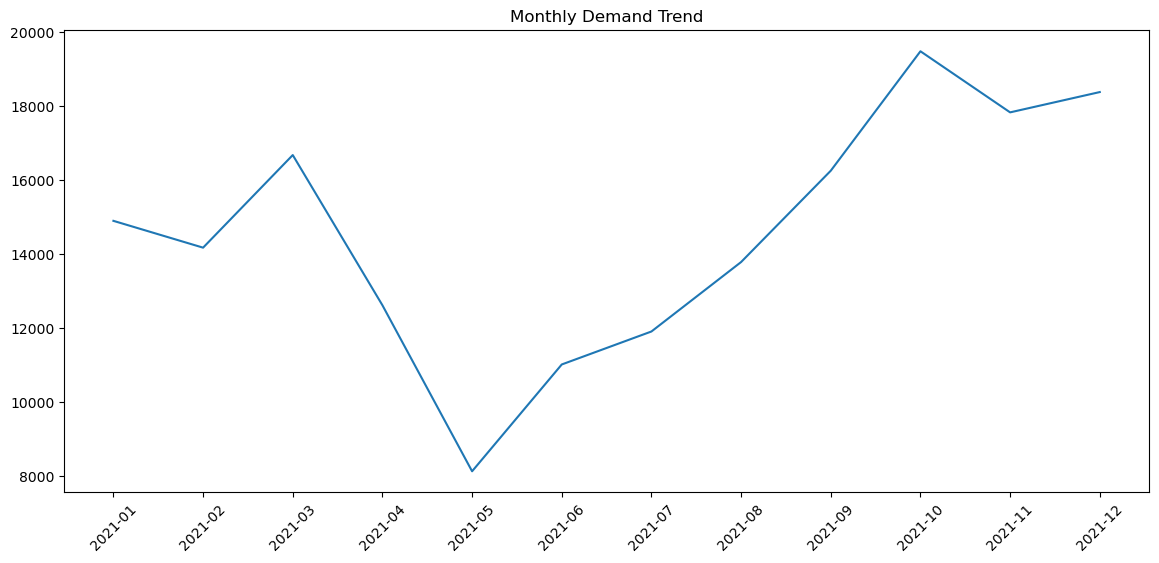

In [4]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_volume['Year_Month'],
    monthly_volume['Billed Qty (CBM)']
)

plt.xticks(rotation=45)

plt.title("Monthly Demand Trend")

plt.show()

In [5]:
quarterly_volume = (
    df.groupby('Quarter')['Billed Qty (CBM)']
      .sum()
      .reset_index()
)

quarterly_volume

,Quarter,Billed Qty (CBM)
0,1,45749.909
1,2,31765.527
2,3,41947.616
3,4,55691.103


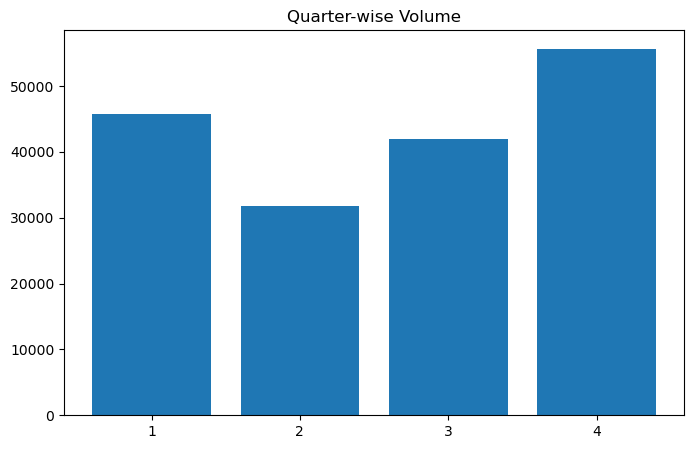

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    quarterly_volume['Quarter'].astype(str),
    quarterly_volume['Billed Qty (CBM)']
)

plt.title("Quarter-wise Volume")

plt.show()

In [7]:
top_territories = (
    df.groupby('Territory')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_territories

Territory
Prelam -Ghaziabad    34389.523
Prelam -Delhi        26953.146
Prelam-Ludhiana      17911.583
Prelam -Jaipur       13037.909
Prelam -Gurgaon       8725.497
Prelam -Lucknow       8593.393
Prelam -Ahmedabad     6386.152
Prelam -Chennai       4803.802
Prelam -Mumbai        4748.274
Prejap1               3744.729
Name: Billed Qty (CBM), dtype: float64

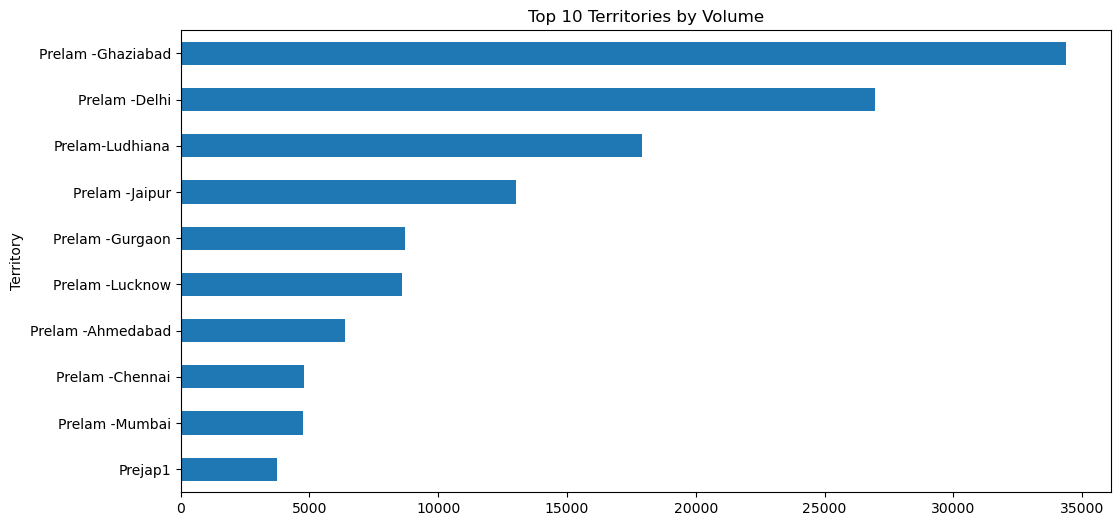

In [8]:
plt.figure(figsize=(12,6))

top_territories.sort_values().plot(kind='barh')

plt.title("Top 10 Territories by Volume")

plt.show()

In [9]:
territory_share = (
    df.groupby('Territory')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
)

territory_share = (
    territory_share /
    territory_share.sum()
) * 100

territory_share.head(10)

Territory
Prelam -Ghaziabad    19.633861
Prelam -Delhi        15.388242
Prelam-Ludhiana      10.226182
Prelam -Jaipur        7.443677
Prelam -Gurgaon       4.981610
Prelam -Lucknow       4.906188
Prelam -Ahmedabad     3.646018
Prelam -Chennai       2.742614
Prelam -Mumbai        2.710911
Prejap1               2.137962
Name: Billed Qty (CBM), dtype: float64

In [10]:
top_customers = (
    df.groupby('Customer Name')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

top_customers

Customer Name
Merino Industries Limited            7900.742
Sachdeva Enterprises                 5286.661
Salasar Distributor                  4868.689
Sehgal Plywood & Timber Merchants    4362.056
Gauri Nandan Wood Products           3365.173
Mega Marketers                       3287.145
Blackwood international              3134.771
Balaji Sales Corporation             3045.271
HIND PLYWOOD                         2962.300
Tanishka enterprises                 2884.811
Shri Krishna Sales Corporation       2215.872
Sri Senthur tradings                 2198.635
Santosh Enterprises                  2131.017
Shri Durga Timber Trading Co.        1950.507
N.K. Traders                         1843.678
Chotia Timber & Plywood              1827.225
RIDHI ENTERPRISES                    1793.030
Mittal Greentech india               1708.192
Anoop plywood                        1678.132
Saluja plywood                       1568.290
Name: Billed Qty (CBM), dtype: float64

In [11]:
customer_share = (
    df.groupby('Customer Name')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
)

top10_share = (
    customer_share.head(10).sum()
    /
    customer_share.sum()
) * 100

print(
    f"Top 10 Customers contribute {top10_share:.2f}% of total volume"
)

Top 10 Customers contribute 23.46% of total volume


In [12]:
top_materials = (
    df.groupby('Material Desc.')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

top_materials

Material Desc.
1.9 MM CEN PLN MDF-DI-E2- A-2.44X1.22       9669.894
11 MM CEN PLN MDF-DI-E2 A-2.44X1.22         7520.781
3.3 MM CEN PLN MDF-DI-E2 A-2.44X1.22        7354.075
16.75 MM CENPLAIN-PREMIUM+E2 A-2.44X1.22    6912.785
5.5 MM CEN PLN MDF-DI-E2 A-2.44X1.22        6542.821
16.5 MM CEN PLN MDF-DI-E2 A-2.44X1.22       5428.046
4.6 MM CEN PLN MDF-DI-E2 A-2.44X1.22        5140.058
18 MM CEN PLAIN-PREMIUM+ E2 A-2.44X1.22     5077.190
7 MM CEN PLN MDF-DI-E2 A-2.44X1.22          5028.825
16.75 MM PP E2 BB B008 BALWHITE MA8X4       3983.529
7.5 MM CEN PLN MDF-DI-E2 A-2.44X1.22        3965.232
16.75 MM PP E2 OB B008 BALWHITE MA8X4       3902.660
4 MM CENPLN MDF-DI-E2R A-2.44X1.22          3867.126
3.3 MM CEN PLN MDF-DW E2 A-2.44X1.22        3516.776
18 MM CENPLNMDF-DI-CARB P2 A-2.745X1.23     3480.575
11 MM CEN PLN MDF- DW E2 A-2.44 X1.22       2982.893
5.5 MM CEN PLN MDF- DW E2 A-2.44 X1.22      2831.639
16.5 MM CEN PLN MDF-DW E2 A-2.44X1.22       2735.227
2.1 MM CEN PLN MDF-DI-E2 A-2.44

In [13]:
thickness_volume = (
    df.groupby('Thickness')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
)

thickness_volume.head(10)

Thickness
18.00    20655.165
16.75    20583.037
5.50     17073.376
11.00    15083.378
16.50    13305.622
3.30     11400.848
1.90     10564.240
7.50      8706.918
17.00     8475.928
4.60      6818.924
Name: Billed Qty (CBM), dtype: float64

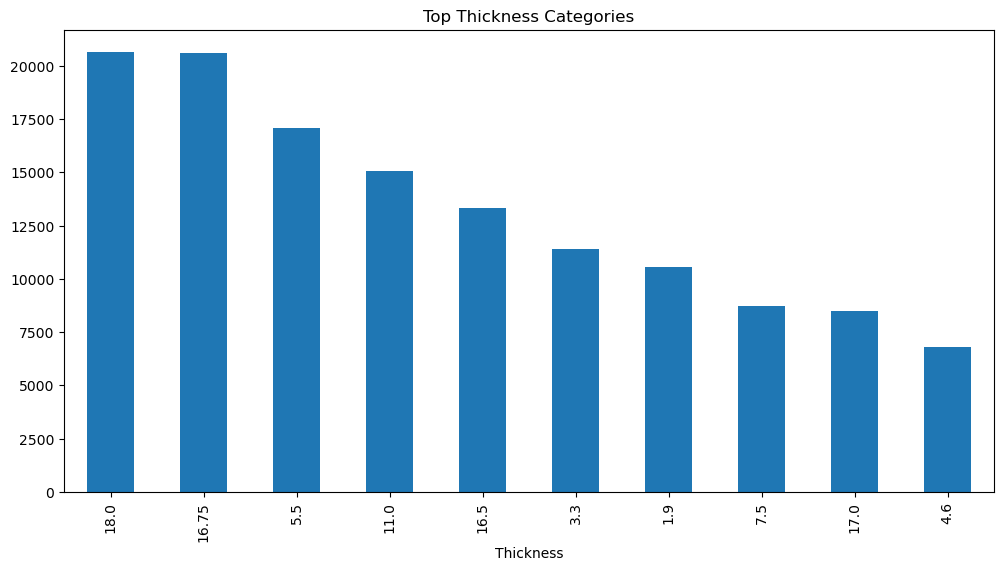

In [14]:
plt.figure(figsize=(12,6))

thickness_volume.head(10).plot(kind='bar')

plt.title("Top Thickness Categories")

plt.show()

In [15]:
division_volume = (
    df.groupby('Division Text')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
)

division_volume

Division Text
MDF - Plain        140265.412
MDF - Laminated     34888.743
Name: Billed Qty (CBM), dtype: float64

In [16]:
territory_share = (
    df.groupby('Territory')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
)

territory_share = (
    territory_share /
    territory_share.sum()
) * 100

territory_share.head(10)

Territory
Prelam -Ghaziabad    19.633861
Prelam -Delhi        15.388242
Prelam-Ludhiana      10.226182
Prelam -Jaipur        7.443677
Prelam -Gurgaon       4.981610
Prelam -Lucknow       4.906188
Prelam -Ahmedabad     3.646018
Prelam -Chennai       2.742614
Prelam -Mumbai        2.710911
Prejap1               2.137962
Name: Billed Qty (CBM), dtype: float64

In [17]:
customer_share = (
    df.groupby('Customer Name')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
)

top10_share = (
    customer_share.head(10).sum()
    /
    customer_share.sum()
) * 100

top20_share = (
    customer_share.head(20).sum()
    /
    customer_share.sum()
) * 100

print("Top 10 Customer Share:", round(top10_share,2))
print("Top 20 Customer Share:", round(top20_share,2))

Top 10 Customer Share: 23.46
Top 20 Customer Share: 34.26


In [18]:
thickness_share = (
    df.groupby('Thickness')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
)

thickness_share = (
    thickness_share /
    thickness_share.sum()
) * 100

thickness_share.head(10)

Thickness
18.00    11.792564
16.75    11.751384
5.50      9.747628
11.00     8.611487
16.50     7.596521
3.30      6.509037
1.90      6.031396
7.50      4.971003
17.00     4.839125
4.60      3.893099
Name: Billed Qty (CBM), dtype: float64